<a href="https://colab.research.google.com/github/puskat-debug/database-assign.ipynb/blob/main/Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pandas numpy matplotlib seaborn scipy --quiet

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

sns.set_theme(style="whitegrid", palette="muted")

path = "/content/drive/MyDrive/Database Assignment/"

customers  = pd.read_csv(path + "customers.csv")
drivers    = pd.read_csv(path + "drivers.csv")
vehicles   = pd.read_csv(path + "vehicles.csv")
hubs       = pd.read_csv(path + "hubs.csv")
orders     = pd.read_csv(path + "orders.csv")
deliveries = pd.read_csv(path + "deliveries.csv")
app_events = pd.read_csv(path + "app_events.csv")
incidents  = pd.read_csv(path + "incidents.csv")
complaints = pd.read_csv(path + "complaints.csv")

print("Files loaded:")
for name, df in [("customers",customers), ("drivers",drivers), ("vehicles",vehicles),
                 ("orders",orders), ("deliveries",deliveries), ("app_events",app_events),
                 ("incidents",incidents), ("complaints",complaints)]:
    print(f"  {name}: {df.shape}")

Files loaded:
  customers: (650, 9)
  drivers: (170, 8)
  vehicles: (120, 8)
  orders: (1250, 11)
  deliveries: (950, 13)
  app_events: (640, 10)
  incidents: (280, 7)
  complaints: (320, 10)


In [5]:
for name, df in [("customers",customers), ("drivers",drivers), ("vehicles",vehicles),
                 ("orders",orders), ("deliveries",deliveries), ("app_events",app_events),
                 ("incidents",incidents), ("complaints",complaints)]:
    print(f"\n{'='*60}")
    print(f"{name}")
    print(f"{'='*60}")
    print(f"Shape: {df.shape}")
    print("Columns:", df.columns.tolist())
    print("\nFirst 3 rows:")
    print(df.head(3))
    missing = df.isnull().sum()
    if missing.any():
        print("\nMissing values:")
        print(missing[missing > 0])
    else:
        print("\nNo missing values")
    print("-" * 40)


customers
Shape: (650, 9)
Columns: ['customer_id', 'age', 'home_zone', 'customer_type', 'signup_date', 'loyalty_score', 'app_engagement_score', 'preferred_channel', 'account_status']

First 3 rows:
  customer_id  age home_zone customer_type          signup_date  \
0       C0001   26     North           SME  2024-11-27 04:25:00   
1       C0002   61   AIRPORT      Consumer  2025-10-28 01:04:00   
2       C0003   66      East      Consumer  2025-07-02 03:23:00   

   loyalty_score  app_engagement_score preferred_channel account_status  
0           44.9                  69.2               App         Active  
1           55.4                  66.6               App         Active  
2           75.9                  33.8               NaN         Active  

Missing values:
loyalty_score        20
preferred_channel    13
dtype: int64
----------------------------------------

drivers
Shape: (170, 8)
Columns: ['driver_id', 'base_zone', 'employment_type', 'years_experience', 'training_score',

In [6]:
for name in ["customers","drivers","vehicles","hubs",
             "orders","deliveries","app_events","incidents","complaints"]:
    df = eval(name)
    df.columns = df.columns.str.strip()
    df.dropna(how="all", inplace=True)
    df.drop_duplicates(inplace=True)
    print(f"Cleaned {name}: {df.shape}")

Cleaned customers: (650, 9)
Cleaned drivers: (170, 8)
Cleaned vehicles: (120, 8)
Cleaned hubs: (8, 5)
Cleaned orders: (1250, 11)
Cleaned deliveries: (950, 13)
Cleaned app_events: (640, 10)
Cleaned incidents: (280, 7)
Cleaned complaints: (320, 10)


In [7]:
zone_map = {
    "ctr": "Central",   "CENTRAL": "Central",   "central": "Central",
    "NORTH": "North",   "north": "North",
    "SOUTH": "South",   "south": "South",
    "EAST":  "East",    "east":  "East",
    "WEST":  "West",    "west":  "West",
    "RiverSide": "Riverside", "RIVERSIDE": "Riverside", "riverside": "Riverside",
    "AIRPORT": "Airport",     "airport": "Airport"
}
def norm_zone(series):
    return series.str.strip().replace(zone_map)

orders["pickup_zone"]      = norm_zone(orders["pickup_zone"])
orders["dropoff_zone"]     = norm_zone(orders["dropoff_zone"])
drivers["base_zone"]       = norm_zone(drivers["base_zone"])
vehicles["assigned_zone"]  = norm_zone(vehicles["assigned_zone"])
app_events["zone_context"] = norm_zone(app_events["zone_context"])

print("Zones after normalisation:", sorted(orders["pickup_zone"].unique()))

Zones after normalisation: ['Airport', 'Central', 'Ctr', 'East', 'North', 'Riverside', 'South', 'West']


In [8]:
for df, col in [(deliveries, "dispatch_time"),
                (deliveries, "delivery_completed_at"),
                (orders,     "order_created_at"),
                (complaints, "created_at")]:
    df[col] = pd.to_datetime(df[col], errors="coerce")

print(f"Missing completion timestamps: {deliveries['delivery_completed_at'].isna().sum()}")

Missing completion timestamps: 19


In [9]:
deliveries["delay_hours"] = (
    deliveries["delivery_completed_at"] - deliveries["dispatch_time"]
).dt.total_seconds() / 3600

dl = deliveries.merge(
    orders[["order_id", "promised_window_hours", "pickup_zone", "service_type"]],
    on="order_id", how="left"
)


dl["window_breached"] = (
    (dl["delay_hours"] > dl["promised_window_hours"]) & dl["delay_hours"].notna()
).astype(int)


dl["high_risk"] = (
    (dl["manual_route_override_count"] >= 3) |
    (dl["proof_of_completion_missing"] == 1) |
    (dl["delivery_status"] == "Failed")
).astype(int)

print(f"Window-breached : {dl['window_breached'].sum()} ({dl['window_breached'].mean()*100:.1f}%)")
print(f"High-risk       : {dl['high_risk'].sum()} ({dl['high_risk'].mean()*100:.1f}%)")

Window-breached : 435 (45.8%)
High-risk       : 245 (25.8%)


Fuel cost outliers: 9 (0.9%)
pickup_zone
Airport      2
South        2
Central      1
Ctr          1
East         1
Riverside    1
West         1
Name: delivery_id, dtype: int64


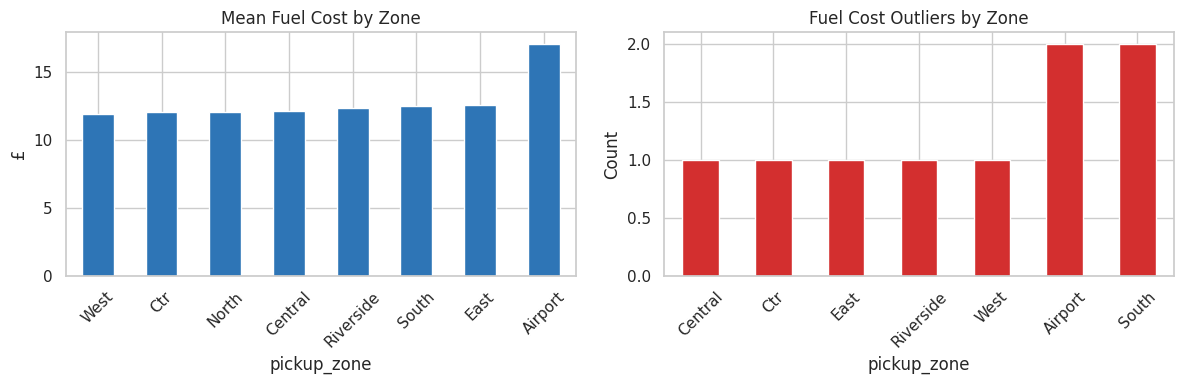

In [10]:
dl["fuel_zscore"] = dl.groupby("pickup_zone")["fuel_or_charge_cost"].transform(
    lambda x: zscore(x, ddof=1)
)
outliers = dl[dl["fuel_zscore"].abs() > 2.5]
print(f"Fuel cost outliers: {len(outliers)} ({len(outliers)/len(dl)*100:.1f}%)")
print(outliers.groupby("pickup_zone")["delivery_id"].count().sort_values(ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
dl.groupby("pickup_zone")["fuel_or_charge_cost"].mean().sort_values().plot(
    kind="bar", ax=axes[0], color="#2E75B6", edgecolor="white"
)
axes[0].set_title("Mean Fuel Cost by Zone")
axes[0].set_ylabel("£")
axes[0].tick_params(axis="x", rotation=45)

outliers.groupby("pickup_zone")["delivery_id"].count().sort_values().plot(
    kind="bar", ax=axes[1], color="#D32F2F", edgecolor="white"
)
axes[1].set_title("Fuel Cost Outliers by Zone")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

delivery_status   Delayed  Failed  OnTime  avg_overrides
incident_type                                           
TemperatureIssue     20.7    20.7    58.6           0.69
AppSyncError         29.0    16.1    54.8           0.65
SafetyNearMiss       14.3    14.3    71.4           1.07
BatteryAlert         16.7    13.9    69.4           0.72
ProofMissing         19.6    13.0    67.4           1.02
RouteDeviation       18.6     9.3    72.1           0.65
VehicleFault         13.5     8.1    78.4           0.73
CustomerNoShow       22.7     6.8    70.5           0.77


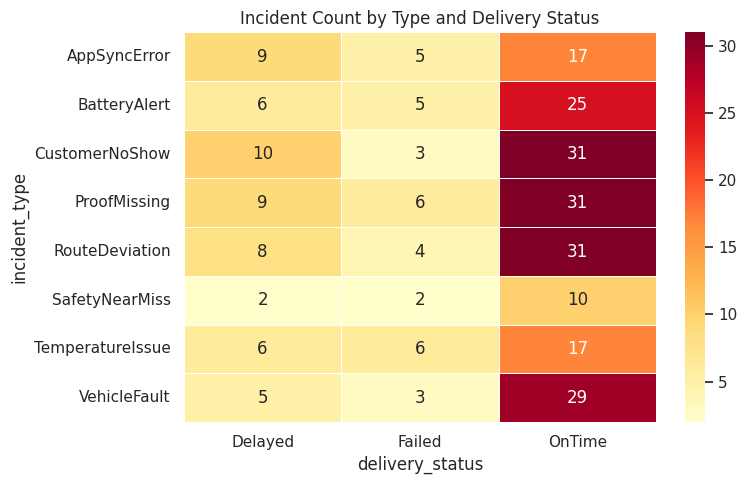

In [11]:
inc_dl = incidents.merge(
    deliveries[["delivery_id", "delivery_status", "manual_route_override_count"]],
    on="delivery_id"
)
pivot = pd.crosstab(
    inc_dl["incident_type"], inc_dl["delivery_status"], normalize="index"
).round(3) * 100
pivot["avg_overrides"] = inc_dl.groupby("incident_type")["manual_route_override_count"].mean().round(2)
print(pivot.sort_values("Failed", ascending=False))

plt.figure(figsize=(8, 5))
sns.heatmap(
    pd.crosstab(inc_dl["incident_type"], inc_dl["delivery_status"]),
    annot=True, fmt="d", cmap="YlOrRd", linewidths=0.5
)
plt.title("Incident Count by Type and Delivery Status")
plt.tight_layout()
plt.show()

Vehicles below 70% battery : 35
Fleet average battery      : 76.8%
Vehicles InRepair          : 36


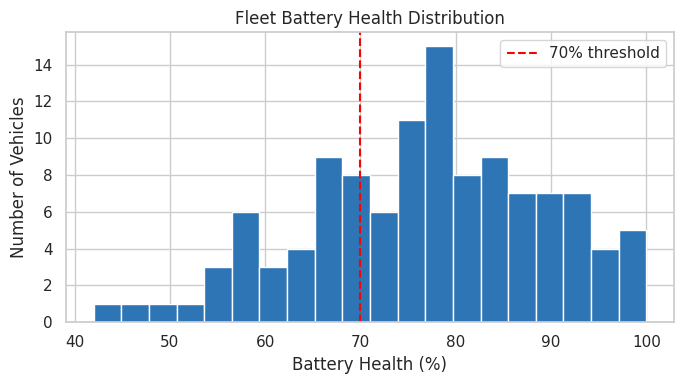

In [12]:
print(f"Vehicles below 70% battery : {(vehicles['battery_health_pct'] < 70).sum()}")
print(f"Fleet average battery      : {vehicles['battery_health_pct'].mean():.1f}%")
print(f"Vehicles InRepair          : {(vehicles['maintenance_status'] == 'InRepair').sum()}")

plt.figure(figsize=(7, 4))
vehicles["battery_health_pct"].hist(bins=20, color="#2E75B6", edgecolor="white")
plt.axvline(70, color="red", linestyle="--", label="70% threshold")
plt.title("Fleet Battery Health Distribution")
plt.xlabel("Battery Health (%)")
plt.ylabel("Number of Vehicles")
plt.legend()
plt.tight_layout()
plt.show()

               avg_complaint_rate  avg_order_value
customer_type                                     
Consumer                    0.265          195.221
Enterprise                  0.256          255.595
SME                         0.228          196.740


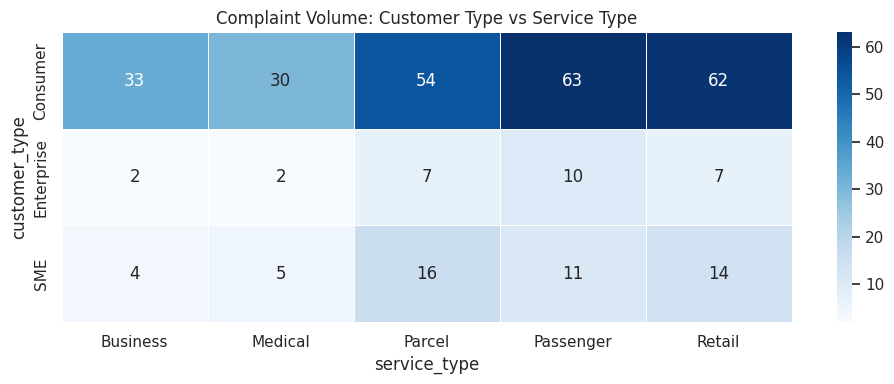

In [16]:
cust_orders = orders.groupby("customer_id").agg(
    total_orders = ("order_id",    "count"),
    total_value  = ("order_value", "sum")
).reset_index()

cust_complaints = complaints.groupby("customer_id").agg(
    complaint_count = ("complaint_id", "count")
).reset_index()

cust_full = (
    cust_orders
    .merge(cust_complaints, on="customer_id", how="left")
    .merge(customers[["customer_id", "customer_type", "loyalty_score"]], on="customer_id", how="left")
)
cust_full["complaint_rate"] = cust_full["complaint_count"].fillna(0) / cust_full["total_orders"]

print(cust_full.groupby("customer_type").agg(
    avg_complaint_rate = ("complaint_rate", "mean"),
    avg_order_value    = ("total_value",    "mean")
).round(3))

heat_data = (
    complaints
    .merge(orders[["order_id", "service_type"]], on="order_id")
    .merge(customers[["customer_id", "customer_type"]], on="customer_id")
)
plt.figure(figsize=(10, 4))
sns.heatmap(
    pd.crosstab(heat_data["customer_type"], heat_data["service_type"]),
    annot=True, fmt="d", cmap="Blues", linewidths=0.5
)
plt.title("Complaint Volume: Customer Type vs Service Type")
plt.tight_layout()
plt.show()